# Preparation QC

Прогон и проверка Stage 1 для одного датасета: composed-конфиг ->
`get_dataset_dir` -> артефакт в `datasets/prepared_cache/`. Датасет выбирается в
`DATASET`, рецепт правится через `OVERRIDES`.

In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf

from preparation import get_dataset_dir

%matplotlib inline
mne.viz.set_browser_backend("matplotlib")
mne.set_log_level("ERROR")
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 80)

DATASET = "sam40"  # "sam40" | "distinguishing"
# Полная разметка датасета — DATASET_MAPPING в src/preparation.py; конфиг и
# командная строка только вычитают из неё имена. Список заменяется целиком,
# поэтому это обычный override:
#   ["dataset.exclude_conditions=[arithmetic,mirror]"]   # relax против stroop
OVERRIDES = []

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
with initialize_config_dir(config_dir=str(PROJECT_ROOT / "configs"), version_base="1.3"):
    cfg = compose(config_name="config", overrides=[f"dataset={DATASET}", *OVERRIDES])

print(OmegaConf.to_yaml(cfg.dataset))
print(OmegaConf.to_yaml(cfg.preparation))

Using matplotlib as 2D backend.


name: sam40
exclude_conditions: []

version: epochs_dataset_v8
l_freq: 0.5
h_freq: 45.0
notch_frequencies:
- 50.0
reference: average
resample_sfreq: 128.0
exclude_session_values:
  session_role:
  - habituation
  session_quality:
  - incomplete
ica_method: fastica
ica_n_components: 0.99
ica_random_state: 42
ica_fit_l_freq: 1.0
ica_fit_h_freq: 45.0
ica_eog_proxy_channels:
- F3
- F4
- F7
- F8
ica_eog_threshold: 2.4
window_size: 5.0
overlap: 0.5
channels:
- F3
- F4
- F7
- F8
- FC5
- FC6
- O1
- O2
- P7
- P8
- T7
- T8



In [2]:
# Первый прогон нового рецепта считает ICA и пишет артефакт (долго);
# при совпадении hash — reuse существующего каталога.
artifact_dir = get_dataset_dir(cfg.dataset, cfg.preparation)
print(sorted(p.name for p in artifact_dir.iterdir()))

Reusing /home/datalake/models_test/python_project/datasets/prepared_cache/9cd181d2
['config.yaml', 'epochs-epo.fif']


## Artifact config

In [3]:
artifact_config = OmegaConf.load(artifact_dir / "config.yaml")
print(OmegaConf.to_yaml(artifact_config, resolve=True))
epochs = mne.read_epochs(artifact_dir / "epochs-epo.fif", preload=True, verbose="ERROR")

dataset:
  name: sam40
  exclude_conditions: []
preparation:
  version: epochs_dataset_v8
  l_freq: 0.5
  h_freq: 45.0
  notch_frequencies:
  - 50.0
  reference: average
  resample_sfreq: 128.0
  exclude_session_values:
    session_role:
    - habituation
    session_quality:
    - incomplete
  ica_method: fastica
  ica_n_components: 0.99
  ica_random_state: 42
  ica_fit_l_freq: 1.0
  ica_fit_h_freq: 45.0
  ica_eog_proxy_channels:
  - F3
  - F4
  - F7
  - F8
  ica_eog_threshold: 2.4
  window_size: 5.0
  overlap: 0.5
  channels:
  - F3
  - F4
  - F7
  - F8
  - FC5
  - FC6
  - O1
  - O2
  - P7
  - P8
  - T7
  - T8



In [4]:
recordings = epochs.metadata
print(f"epochs total: {len(epochs)}")
recordings.groupby(["subject", "recording_unit", "task"], dropna=False).size().describe()

epochs total: 2400


count    480.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
dtype: float64

In [5]:
print("ICA diagnostics are not stored in the prepared artifact.")

ICA diagnostics are not stored in the prepared artifact.


## Epochs

In [6]:
epochs = mne.read_epochs(artifact_dir / "epochs-epo.fif", preload=True, verbose="ERROR")
data = epochs.get_data(copy=False)
print(epochs)
print(f"event_id: {epochs.event_id}")
print(f"data: {data.shape}, {epochs.tmin:.3f}..{epochs.tmax:.3f} s @ {epochs.info['sfreq']} Hz")
print(f"amplitude uV: p99={np.percentile(np.abs(data), 99) * 1e6:.1f}, max={np.abs(data).max() * 1e6:.1f}")
print(f"non-finite samples: {int((~np.isfinite(data)).sum())}")
print(f"config dataset matches: {artifact_config.dataset.name == cfg.dataset.name}")
epochs.metadata.head()

<EpochsFIF | 2400 events (all good), 0 – 4.992 s (baseline off), ~140.7 MiB, data loaded, with metadata,
 'high_attention': 1800
 'low_attention': 600>
event_id: {'high_attention': 1, 'low_attention': 0}
data: (2400, 12, 640), 0.000..4.992 s @ 128.0 Hz


amplitude uV: p99=20.8, max=301.3
non-finite samples: 0
config dataset matches: True


,dataset,subject,session,task,run,recording_unit,label,condition,window_start_s,window_stop_s
0,sam40,01,None,arithmetic,01,sam40_01_run-01,1,arithmetic,0.0,5.0
1,sam40,01,None,arithmetic,01,sam40_01_run-01,1,arithmetic,4.5,9.5
2,sam40,01,None,arithmetic,01,sam40_01_run-01,1,arithmetic,9.0,14.0
3,sam40,01,None,arithmetic,01,sam40_01_run-01,1,arithmetic,13.5,18.5
4,sam40,01,None,arithmetic,01,sam40_01_run-01,1,arithmetic,18.0,23.0


In [7]:
meta = epochs.metadata
print(f"labels: {meta['label'].value_counts().to_dict()}")
print(f"conditions: {meta['condition'].value_counts().to_dict()}")
print(f"tasks: {meta['task'].value_counts().to_dict()}")
print(f"subjects: {meta['subject'].nunique()}, "
      f"units per subject: {sorted(meta.groupby('subject')['recording_unit'].nunique().unique())}")

# Ключ группировки Stage 2: ses-* у Distinguishing, run-* у SAM40. Все окна и все
# записи юнита должны уходить на одну сторону сплита, потому что ICA оценивалась
# по ним совместно.
per_unit = meta["recording_unit"].value_counts()
print(f"\nunits: {len(per_unit)}, windows per unit: min={per_unit.min()} max={per_unit.max()}")
# Исключённая условием задача не должна была дойти даже до ICA fit, поэтому задач
# на юнит ровно столько, сколько условий осталось после exclude_conditions.
print(f"tasks per unit: {sorted(meta.groupby('recording_unit')['task'].nunique().unique())}")
meta.pivot_table(index="subject", columns="label", values="window_start_s", aggfunc="count", fill_value=0)

labels: {1: 1800, 0: 600}
conditions: {'arithmetic': 600, 'mirror': 600, 'relax': 600, 'stroop': 600}
tasks: {'arithmetic': 600, 'mirror': 600, 'relax': 600, 'stroop': 600}
subjects: 40, units per subject: [np.int64(3)]

units: 120, windows per unit: min=20 max=20
tasks per unit: [np.int64(4)]


label,0,1
subject,,
01,15,45
02,15,45
03,15,45
04,15,45
05,15,45
06,15,45
07,15,45
08,15,45
09,15,45


In [8]:
# Баланс классов внутри субъекта: перекос виден сразу, до всякого CV.
balance = meta.groupby(["subject", "label"]).size().unstack(fill_value=0)
balance["share_1"] = balance.get(1, 0) / balance.sum(axis=1)
print(balance["share_1"].describe())
balance

count    40.00
mean      0.75
std       0.00
min       0.75
25%       0.75
50%       0.75
75%       0.75
max       0.75
Name: share_1, dtype: float64


label,0,1,share_1
subject,,,
01,15,45,0.75
02,15,45,0.75
03,15,45,0.75
04,15,45,0.75
05,15,45,0.75
06,15,45,0.75
07,15,45,0.75
08,15,45,0.75
09,15,45,0.75


## Визуальная проверка

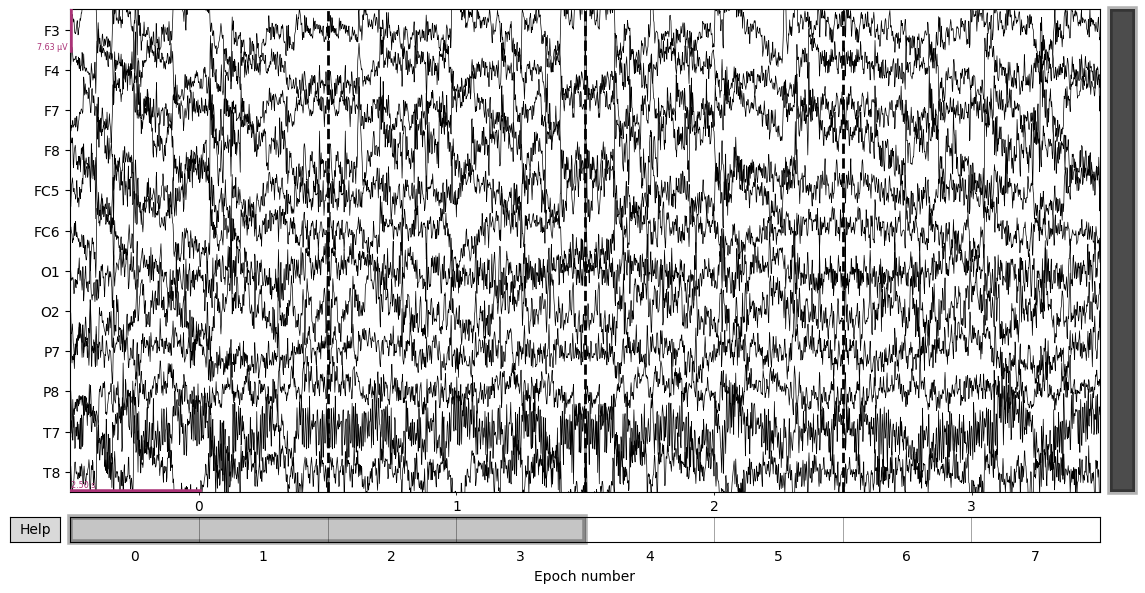

In [9]:
fig = epochs[:8].plot(n_epochs=4, n_channels=len(epochs.ch_names), scalings="auto", show=False)
fig.set_size_inches(12, 6)

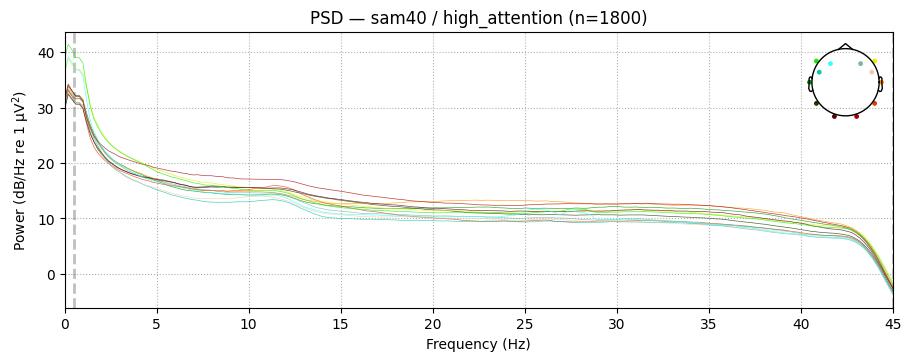

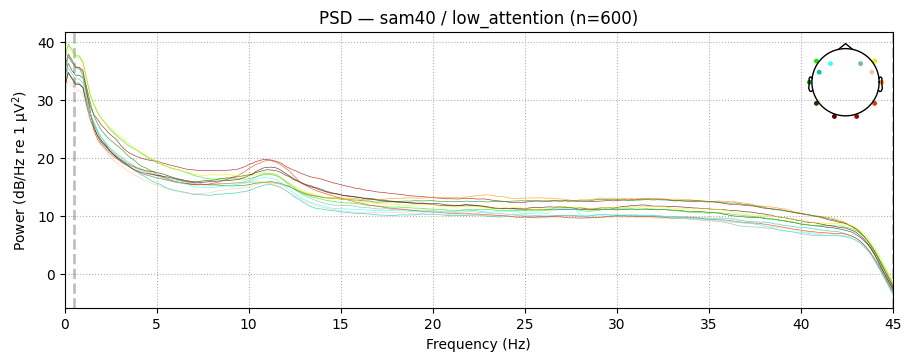

In [10]:
for name in epochs.event_id:
    fig = epochs[name].compute_psd(fmax=45.0, verbose="ERROR").plot(show=False)
    fig.set_size_inches(9, 3.5)
    fig.axes[0].set_title(f"PSD — {DATASET} / {name} (n={len(epochs[name])})")